In [2]:
pip install pandas


   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ------- -------------------------------- 2.1/11.3 MB 13.0 MB/s eta 0:00:01
   -------------------- ------------------- 5.8/11.3 MB 15.3 MB/s eta 0:00:01
   ---------------------------------- ----- 9.7/11.3 MB 16.8 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 16.5 MB/s  0:00:00

   ---------------------------------------- 0/2 [pytz]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pa

In [4]:
import os, sys
from pathlib import Path

# Find project root containing src/
p = Path().resolve()
project_root = None
for parent in [p] + list(p.parents):
    if (parent / "src").is_dir():
        project_root = parent
        break
if project_root is None:
    raise FileNotFoundError("Could not find project root containing 'src' folder.")

os.chdir(project_root)
sys.path.insert(0, str(project_root))

print("Working directory:", Path().resolve())
print("src exists:", (Path("src").is_dir()))

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt


Working directory: E:\dl_cv_mini_project\road_lane_detection
src exists: True


In [5]:
from src.models import UNetSmall
from src.dataset import TuSimpleSegmentationDataset
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

CKPT_PATH = Path("models/checkpoints/unet_tusimple_best.pt")
assert CKPT_PATH.exists(), f"Checkpoint not found: {CKPT_PATH.resolve()}"

ckpt = torch.load(CKPT_PATH, map_location=device)
model = UNetSmall().to(device)
model.load_state_dict(ckpt["model"])
model.eval()

print("Loaded checkpoint:", CKPT_PATH.resolve())
if "epoch" in ckpt:
    print("Checkpoint epoch:", ckpt["epoch"])

# Validation dataset
val_ds = TuSimpleSegmentationDataset(split="val")
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0)
print("Val samples:", len(val_ds))


Device: cuda
Loaded checkpoint: E:\dl_cv_mini_project\road_lane_detection\models\checkpoints\unet_tusimple_best.pt
Checkpoint epoch: 14
Val samples: 362


C:\Users\ankit\AppData\Local\Temp\ipykernel_28400\3076102023.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT_PATH, map_location=device)


In [6]:
def dice_score(pred, target, eps=1e-8):
    # pred/target: {0,1} tensors
    inter = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    return ((2*inter + eps) / (union + eps)).mean().item()

def iou_score(pred, target, eps=1e-8):
    inter = (pred * target).sum(dim=(1,2,3))
    union = ((pred + target) > 0).float().sum(dim=(1,2,3))
    return ((inter + eps) / (union + eps)).mean().item()

def precision_score(pred, target, eps=1e-8):
    tp = (pred * target).sum(dim=(1,2,3))
    fp = (pred * (1-target)).sum(dim=(1,2,3))
    return ((tp + eps) / (tp + fp + eps)).mean().item()

def recall_score(pred, target, eps=1e-8):
    tp = (pred * target).sum(dim=(1,2,3))
    fn = ((1-pred) * target).sum(dim=(1,2,3))
    return ((tp + eps) / (tp + fn + eps)).mean().item()

def f1_score(pred, target, eps=1e-8):
    p = precision_score(pred, target, eps)
    r = recall_score(pred, target, eps)
    return (2*p*r / (p + r + eps))


In [7]:
THR = 0.30  # you can set 0.35 if you prefer

all_dice, all_iou, all_prec, all_rec, all_f1 = [], [], [], [], []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        y = y.to(device).float()  # y: (B,1,H,W) in {0,1}

        logits = model(x)
        prob = torch.sigmoid(logits)
        pred = (prob >= THR).float()

        all_dice.append(dice_score(pred, y))
        all_iou.append(iou_score(pred, y))
        all_prec.append(precision_score(pred, y))
        all_rec.append(recall_score(pred, y))
        all_f1.append(f1_score(pred, y))

print("===== UNET VALIDATION RESULTS =====")
print(f"Threshold      : {THR}")
print(f"Dice Score     : {np.mean(all_dice):.4f}")
print(f"IoU Score      : {np.mean(all_iou):.4f}")
print(f"Precision      : {np.mean(all_prec):.4f}")
print(f"Recall         : {np.mean(all_rec):.4f}")
print(f"F1 Score       : {np.mean(all_f1):.4f}")
print("===================================")


===== UNET VALIDATION RESULTS =====
Threshold      : 0.3
Dice Score     : 0.5173
IoU Score      : 0.3512
Precision      : 0.3597
Recall         : 0.9305
F1 Score       : 0.5187


In [8]:
def unet_to_hough_overlay(img_rgb_u8, prob_hw, thresh=0.30, min_line_length=40, max_line_gap=25):
    """
    img_rgb_u8: (H,W,3) RGB uint8
    prob_hw: (H,W) float [0,1]
    returns overlay_rgb_u8, binary_mask_u8, edges_roi_u8, lines
    """
    H, W = prob_hw.shape

    mask = (prob_hw >= thresh).astype(np.uint8) * 255

    # clean mask
    k_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k_open, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k_close, iterations=2)

    edges = cv2.Canny(mask, 50, 150)

    # ROI
    roi = np.zeros_like(edges)
    poly = np.array([[
        (int(0.05 * W), H),
        (int(0.45 * W), int(0.60 * H)),
        (int(0.55 * W), int(0.60 * H)),
        (int(0.95 * W), H),
    ]], dtype=np.int32)
    cv2.fillPoly(roi, poly, 255)
    edges_roi = cv2.bitwise_and(edges, roi)

    lines = cv2.HoughLinesP(
        edges_roi,
        rho=1,
        theta=np.pi / 180,
        threshold=30,
        minLineLength=min_line_length,
        maxLineGap=max_line_gap,
    )

    overlay = img_rgb_u8.copy()
    if lines is not None:
        for x1, y1, x2, y2 in lines.reshape(-1, 4):
            cv2.line(overlay, (x1, y1), (x2, y2), (255, 0, 0), 3)  # red in RGB

    return overlay, mask, edges_roi, lines


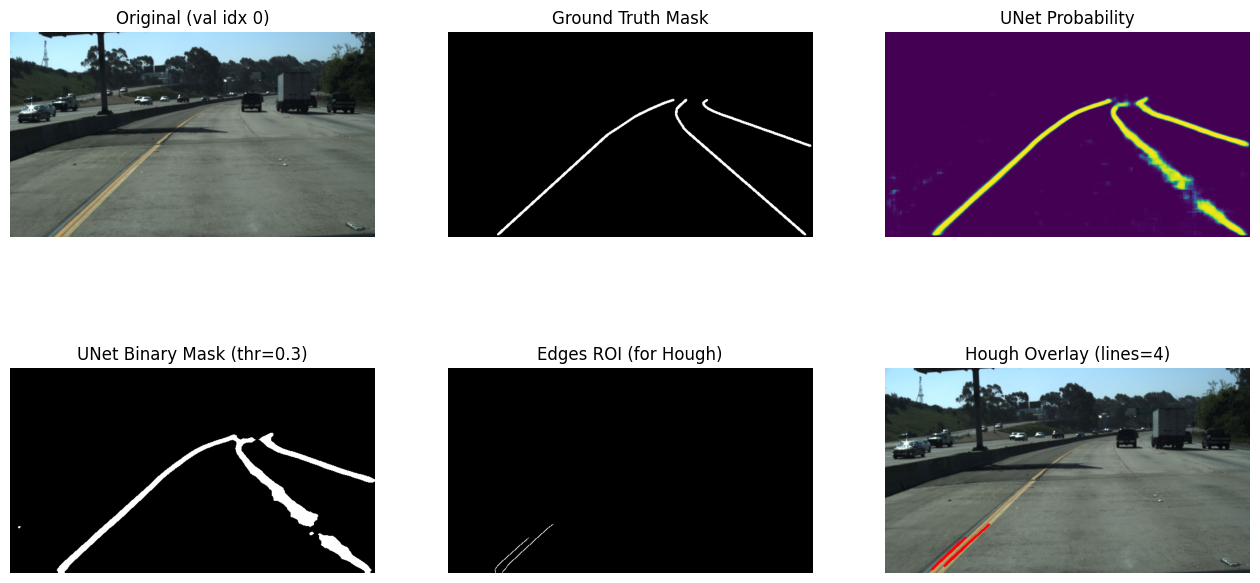

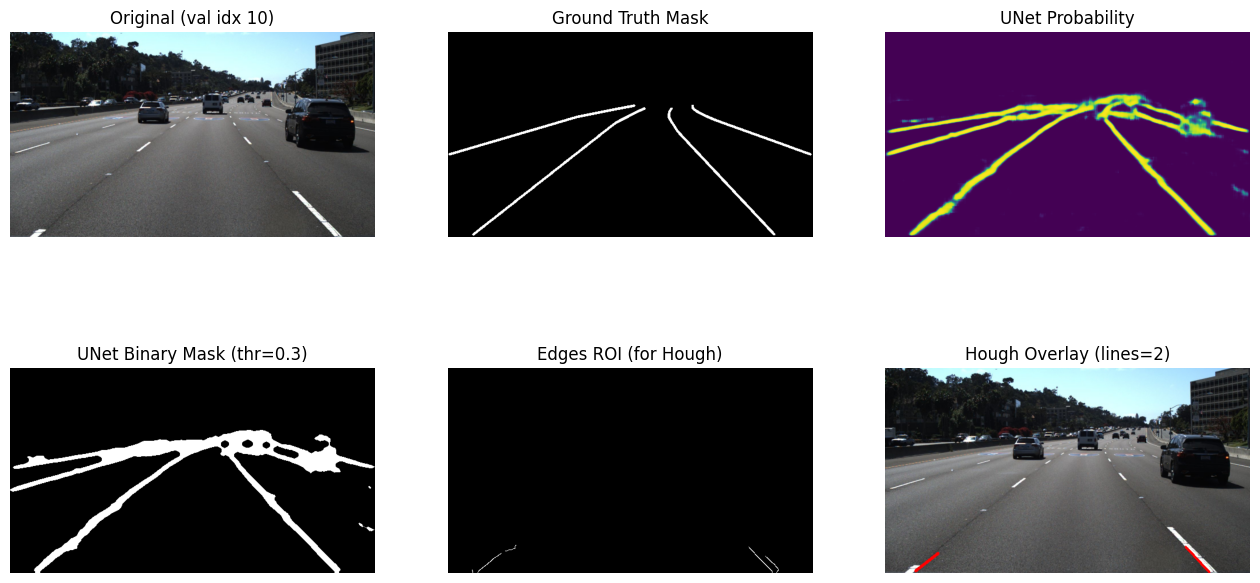

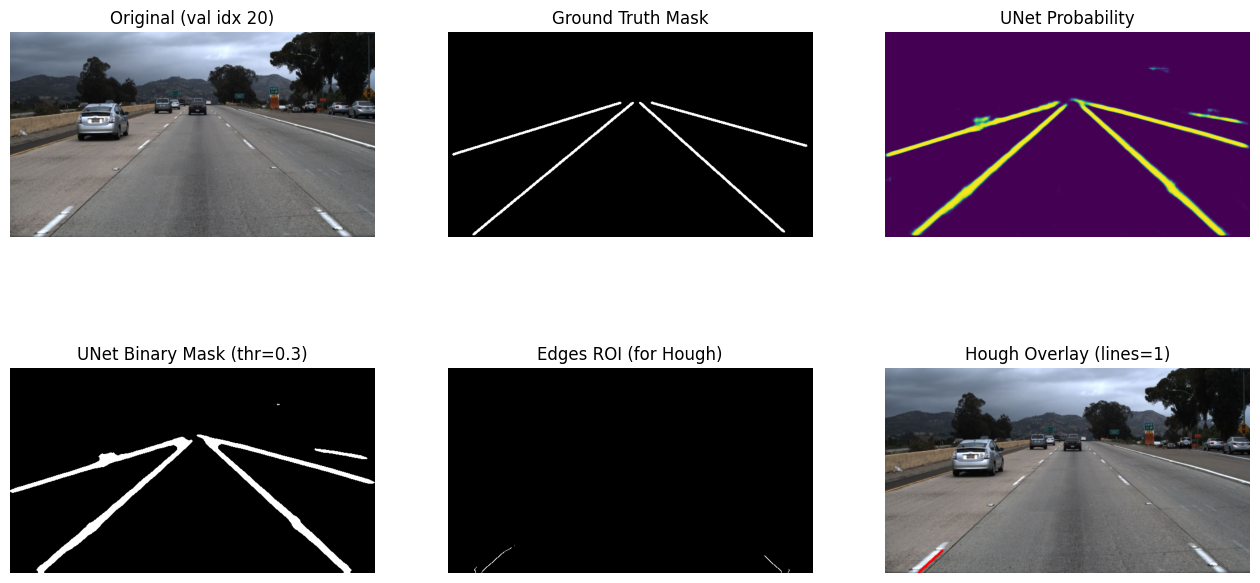

In [9]:
def tensor_to_rgb_u8(x_chw):
    # x_chw: torch tensor CHW in [0,1]
    img = x_chw.detach().cpu().numpy().transpose(1,2,0)
    img_u8 = (np.clip(img, 0, 1) * 255).astype(np.uint8)
    return img_u8

def tensor_to_mask_u8(y_1hw):
    m = y_1hw.detach().cpu().numpy().squeeze()
    return (m > 0.5).astype(np.uint8) * 255

def show_val_examples(indices=[0, 3, 7], thr=0.30):
    for idx in indices:
        x, y = val_ds[idx]
        x1 = x.unsqueeze(0).to(device)

        with torch.no_grad():
            logits = model(x1)
            prob = torch.sigmoid(logits)[0,0].detach().cpu().numpy()  # HxW

        img_rgb = tensor_to_rgb_u8(x)
        gt = tensor_to_mask_u8(y)

        overlay, mask_u8, edges_roi, lines = unet_to_hough_overlay(img_rgb, prob, thresh=thr)

        plt.figure(figsize=(16, 8))

        plt.subplot(2,3,1); plt.imshow(img_rgb); plt.title(f"Original (val idx {idx})"); plt.axis("off")
        plt.subplot(2,3,2); plt.imshow(gt, cmap="gray"); plt.title("Ground Truth Mask"); plt.axis("off")
        plt.subplot(2,3,3); plt.imshow(prob, cmap="viridis"); plt.title("UNet Probability"); plt.axis("off")

        plt.subplot(2,3,4); plt.imshow(mask_u8, cmap="gray"); plt.title(f"UNet Binary Mask (thr={thr})"); plt.axis("off")
        plt.subplot(2,3,5); plt.imshow(edges_roi, cmap="gray"); plt.title("Edges ROI (for Hough)"); plt.axis("off")
        plt.subplot(2,3,6); plt.imshow(overlay); plt.title(f"Hough Overlay (lines={0 if lines is None else len(lines)})"); plt.axis("off")

        plt.show()

show_val_examples(indices=[0, 10, 20], thr=THR)


Selected test images: 20


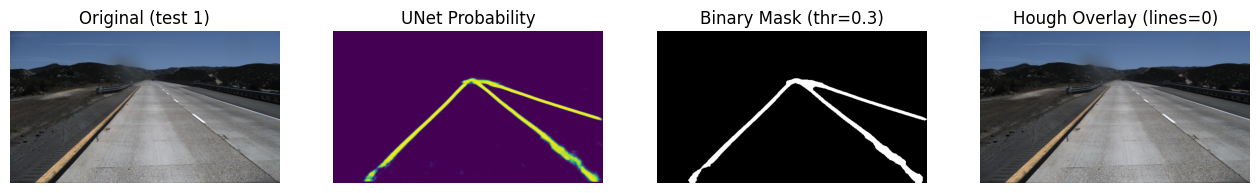

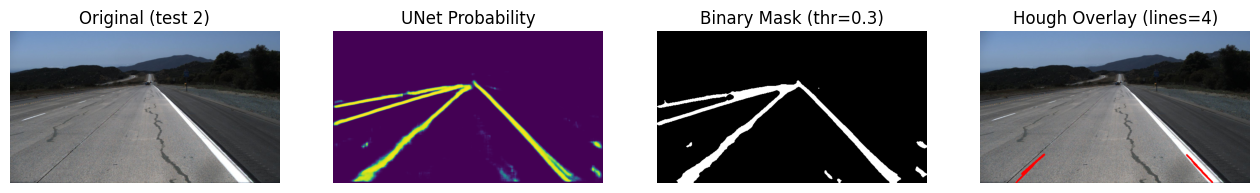

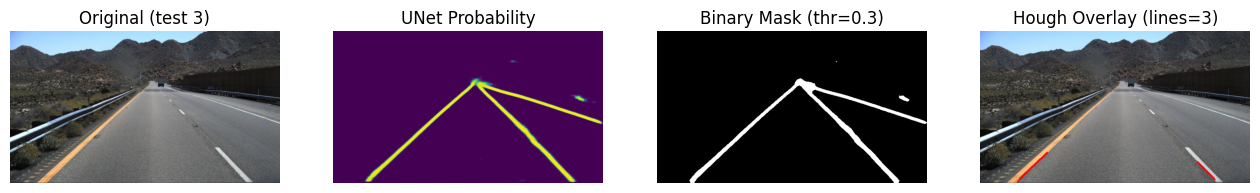

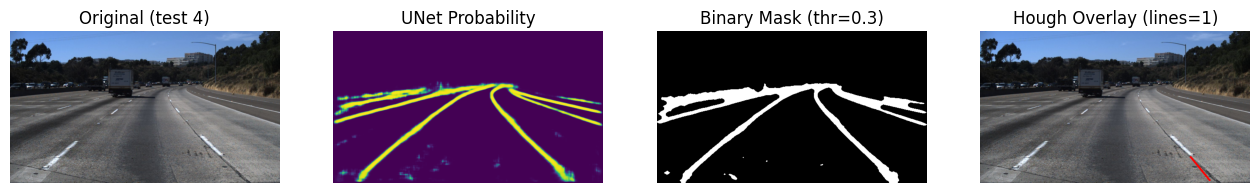

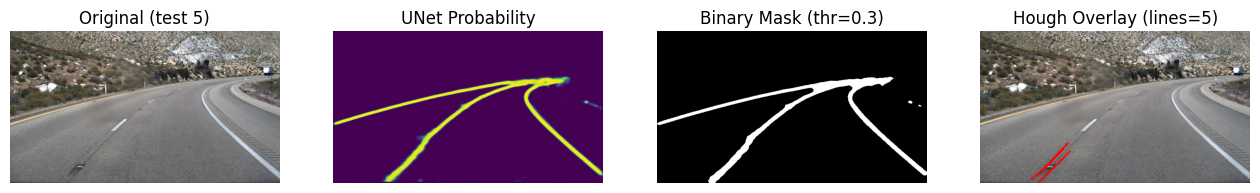

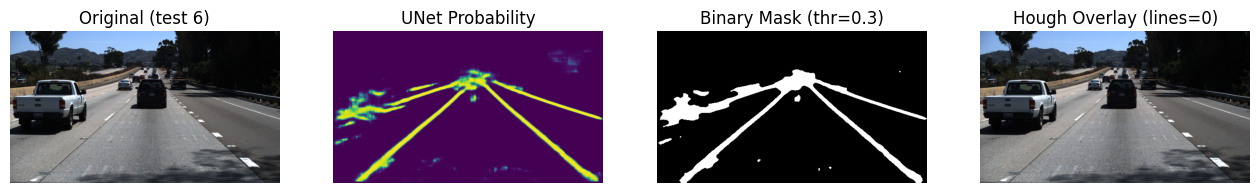

In [10]:
selected_txt = Path("outputs/random_test_results/selected_files.txt")
assert selected_txt.exists(), f"Missing: {selected_txt.resolve()}"

test_paths = [x.strip() for x in selected_txt.read_text(encoding="utf-8").splitlines() if x.strip()]
print("Selected test images:", len(test_paths))

def show_test_examples(show_n=6, thr=0.30):
    show_n = min(show_n, len(test_paths))
    for i in range(show_n):
        p = Path(test_paths[i])
        img_bgr = cv2.imread(str(p))
        if img_bgr is None:
            print("[WARN] Cannot read:", p)
            continue

        # preprocess as model expects
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_rgb = cv2.resize(img_rgb, (640, 360), interpolation=cv2.INTER_LINEAR)
        x = (img_rgb.astype(np.float32) / 255.0)
        x = torch.from_numpy(x).permute(2,0,1).unsqueeze(0).to(device)

        with torch.no_grad():
            prob = torch.sigmoid(model(x))[0,0].detach().cpu().numpy()

        overlay, mask_u8, edges_roi, lines = unet_to_hough_overlay(img_rgb, prob, thresh=thr)

        plt.figure(figsize=(16, 6))
        plt.subplot(1,4,1); plt.imshow(img_rgb); plt.title(f"Original (test {i+1})"); plt.axis("off")
        plt.subplot(1,4,2); plt.imshow(prob, cmap="viridis"); plt.title("UNet Probability"); plt.axis("off")
        plt.subplot(1,4,3); plt.imshow(mask_u8, cmap="gray"); plt.title(f"Binary Mask (thr={thr})"); plt.axis("off")
        plt.subplot(1,4,4); plt.imshow(overlay); plt.title(f"Hough Overlay (lines={0 if lines is None else len(lines)})"); plt.axis("off")
        plt.show()

show_test_examples(show_n=6, thr=THR)


In [12]:
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


In [14]:
from pathlib import Path

log_path = Path("outputs/unet_train_log.txt")
assert log_path.exists(), f"Log file not found: {log_path.resolve()}"
print("Using log:", log_path.resolve())


Using log: E:\dl_cv_mini_project\road_lane_detection\outputs\unet_train_log.txt


In [17]:
import re
from pathlib import Path
import pandas as pd

log_path = Path("outputs/unet_train_log1.txt")
assert log_path.exists(), f"Log not found: {log_path.resolve()}"

text = log_path.read_text(encoding="utf-8", errors="ignore")

# Matches: [Epoch 01] Train Loss: 0.6944 | Val Dice: 0.2001
pat = re.compile(
    r"\[Epoch\s+(\d+)\]\s+Train Loss:\s*([0-9.]+)\s*\|\s*Val Dice:\s*([0-9.]+)",
    flags=re.IGNORECASE
)

rows = []
for m in pat.finditer(text):
    rows.append((int(m.group(1)), float(m.group(2)), float(m.group(3))))

df = pd.DataFrame(rows, columns=["epoch", "train_loss", "val_dice"]).sort_values("epoch").reset_index(drop=True)

print("Parsed epochs:", len(df))
if len(df) == 0:
    print("Nothing parsed. Check that your file contains lines like: [Epoch 01] Train Loss: ... | Val Dice: ...")
else:
    print(df.head(10))


Parsed epochs: 15
   epoch  train_loss  val_dice
0      1      0.6944    0.2001
1      2      0.5364    0.3659
2      3      0.4811    0.3702
3      4      0.4503    0.4304
4      5      0.4312    0.4612
5      6      0.4182    0.4585
6      7      0.4106    0.4434
7      8      0.3986    0.4543
8      9      0.3724    0.4872
9     10      0.3643    0.5019


In [18]:
import re

# Extract epoch durations like: Epoch 1/15 ... [02:53<00:00, ...]
pat_time = re.compile(r"Epoch\s+(\d+)/\d+:\s+.*\[(\d+):(\d+)<")

time_map = {}
for m in pat_time.finditer(text):
    ep = int(m.group(1))
    mm = int(m.group(2))
    ss = int(m.group(3))
    time_map[ep] = mm * 60 + ss

df["epoch_time_sec"] = df["epoch"].map(time_map)

print("Epoch times parsed for:", df["epoch_time_sec"].notna().sum(), "epochs")
print(df[["epoch", "epoch_time_sec"]].head(10))


Epoch times parsed for: 15 epochs
   epoch  epoch_time_sec
0      1             173
1      2             167
2      3             158
3      4             157
4      5             155
5      6             159
6      7             162
7      8             158
8      9             158
9     10             158


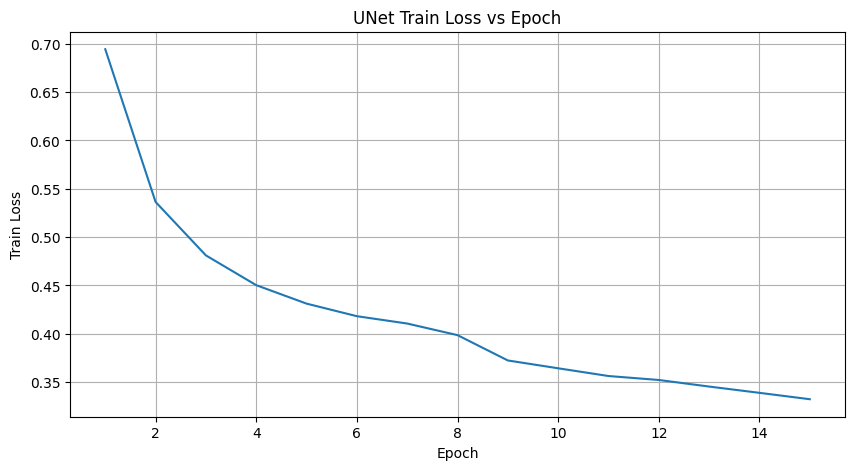

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df["epoch"], df["train_loss"])
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("UNet Train Loss vs Epoch")
plt.grid(True)
plt.show()


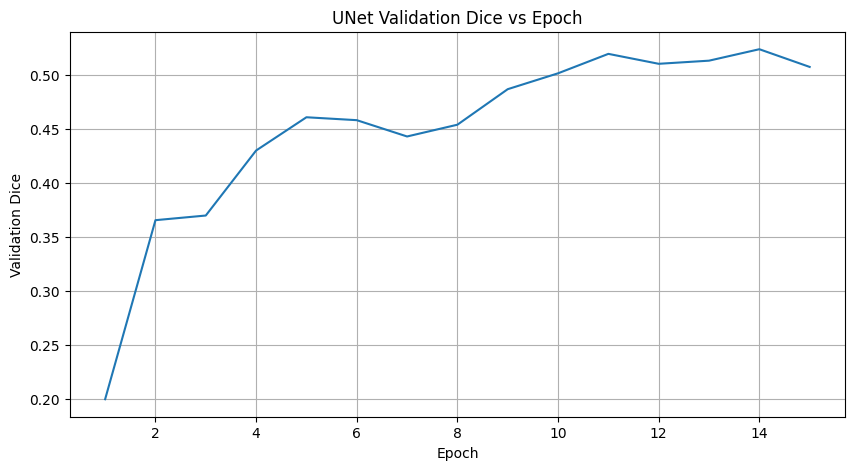

In [20]:
plt.figure(figsize=(10,5))
plt.plot(df["epoch"], df["val_dice"])
plt.xlabel("Epoch")
plt.ylabel("Validation Dice")
plt.title("UNet Validation Dice vs Epoch")
plt.grid(True)
plt.show()


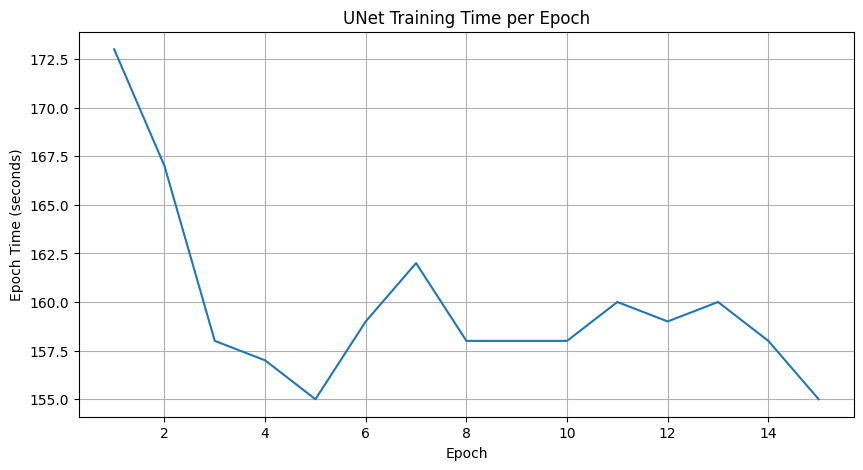

Total training time: 0h 39m 57s


In [21]:
if df["epoch_time_sec"].notna().any():
    plt.figure(figsize=(10,5))
    plt.plot(df["epoch"], df["epoch_time_sec"])
    plt.xlabel("Epoch")
    plt.ylabel("Epoch Time (seconds)")
    plt.title("UNet Training Time per Epoch")
    plt.grid(True)
    plt.show()

    total = int(df["epoch_time_sec"].dropna().sum())
    print("Total training time:", f"{total//3600}h {(total%3600)//60}m {total%60}s")
else:
    print("No epoch-time info found in your log.")


In [22]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cv2
from ultralytics import YOLO

FIG_DIR = Path("outputs/report_figures_yolo")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Saving figures to:", FIG_DIR.resolve())


Saving figures to: E:\dl_cv_mini_project\road_lane_detection\outputs\report_figures_yolo


In [23]:
def find_latest_yolo_run():
    base = Path("runs/segment")
    assert base.exists(), f"{base.resolve()} not found. Train YOLO first."

    runs = []
    for d in base.glob("train*"):
        csv_path = d / "results.csv"
        best_pt = d / "weights" / "best.pt"
        if csv_path.exists():
            runs.append((d, csv_path, best_pt))

    assert runs, "No YOLO runs found under runs/segment/train*/results.csv"

    # Sort by last modified of results.csv
    runs.sort(key=lambda x: x[1].stat().st_mtime, reverse=True)
    return runs[0]

RUN_DIR, YOLO_CSV, YOLO_BEST = find_latest_yolo_run()
print("Using YOLO run folder:", RUN_DIR.resolve())
print("Using results.csv:", YOLO_CSV.resolve())
print("Using best.pt:", YOLO_BEST.resolve(), "| exists:", YOLO_BEST.exists())


Using YOLO run folder: E:\dl_cv_mini_project\road_lane_detection\runs\segment\train2
Using results.csv: E:\dl_cv_mini_project\road_lane_detection\runs\segment\train2\results.csv
Using best.pt: E:\dl_cv_mini_project\road_lane_detection\runs\segment\train2\weights\best.pt | exists: True


In [24]:
dfy = pd.read_csv(YOLO_CSV)
dfy.columns = [c.strip() for c in dfy.columns]

print("Columns found:")
print(dfy.columns.tolist())
display(dfy.head())


Columns found:
['epoch', 'time', 'train/box_loss', 'train/seg_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'metrics/precision(M)', 'metrics/recall(M)', 'metrics/mAP50(M)', 'metrics/mAP50-95(M)', 'val/box_loss', 'val/seg_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


,epoch,time,train/box_loss,train/seg_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),...,metrics/recall(M),metrics/mAP50(M),metrics/mAP50-95(M),val/box_loss,val/seg_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,224.922,1.17879,1.51554,1.95848,1.38776,0.45233,0.78988,0.50265,0.31133,...,0.35218,0.14736,0.03090,1.18780,1.04542,1.55905,1.66118,0.000665,0.000665,0.000665
1,2,444.740,1.15061,1.29508,1.29620,1.34214,0.61132,0.69628,0.68583,0.48516,...,0.31664,0.14801,0.03316,0.95367,0.91738,1.10135,1.39506,0.001330,0.001330,0.001330
2,3,668.923,1.09208,1.23401,1.25624,1.30130,0.57127,0.67690,0.65008,0.43206,...,0.37157,0.18124,0.04211,1.06645,0.84582,1.15887,1.48165,0.001991,0.001991,0.001991
3,4,891.433,1.04605,1.22420,1.21116,1.26196,0.62973,0.70598,0.70948,0.50893,...,0.41357,0.23366,0.05900,0.89671,0.81361,1.04084,1.34098,0.001982,0.001982,0.001982
4,5,1110.190,1.00589,1.12836,1.16628,1.24220,0.64987,0.69305,0.70626,0.51608,...,0.45396,0.31502,0.08085,0.88100,0.72222,1.01750,1.32526,0.001969,0.001969,0.001969


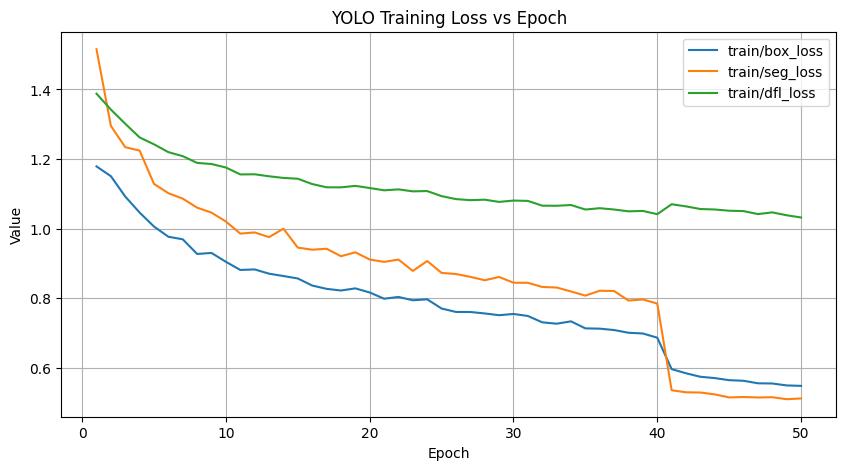

Saved: E:\dl_cv_mini_project\road_lane_detection\outputs\report_figures_yolo\yolo_train_losses.png


In [25]:
def plot_cols(dfy, cols, title, save_name):
    plt.figure(figsize=(10,5))
    for c in cols:
        if c in dfy.columns:
            plt.plot(dfy["epoch"], dfy[c], label=c)
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    out = FIG_DIR / save_name
    plt.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", out.resolve())

loss_cols = ["train/box_loss", "train/seg_loss", "train/dfl_loss"]
plot_cols(dfy, loss_cols, "YOLO Training Loss vs Epoch", "yolo_train_losses.png")


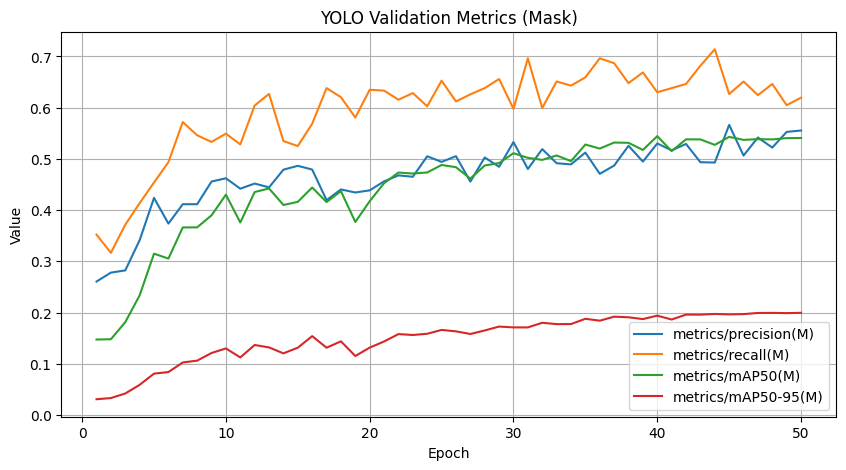

Saved: E:\dl_cv_mini_project\road_lane_detection\outputs\report_figures_yolo\yolo_mask_metrics.png


In [26]:
mask_cols = [
    "metrics/precision(M)", "metrics/recall(M)",
    "metrics/mAP50(M)", "metrics/mAP50-95(M)"
]
plot_cols(dfy, mask_cols, "YOLO Validation Metrics (Mask)", "yolo_mask_metrics.png")


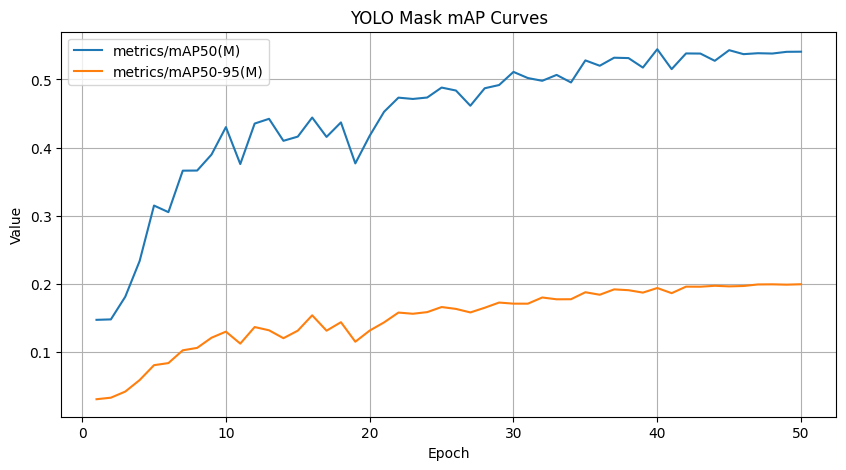

Saved: E:\dl_cv_mini_project\road_lane_detection\outputs\report_figures_yolo\yolo_mask_map.png


In [27]:
mask_map_cols = ["metrics/mAP50(M)", "metrics/mAP50-95(M)"]
plot_cols(dfy, mask_map_cols, "YOLO Mask mAP Curves", "yolo_mask_map.png")


In [28]:
def best_metric(col):
    if col not in dfy.columns:
        return None
    i = dfy[col].idxmax()
    return float(dfy.loc[i, col]), int(dfy.loc[i, "epoch"])

best_map50 = best_metric("metrics/mAP50(M)")
best_map5095 = best_metric("metrics/mAP50-95(M)")

print("===== YOLO BEST MASK METRICS =====")
if best_map50:
    print(f"Best Mask mAP50     : {best_map50[0]:.4f} at epoch {best_map50[1]}")
if best_map5095:
    print(f"Best Mask mAP50-95  : {best_map5095[0]:.4f} at epoch {best_map5095[1]}")
print("==================================")


===== YOLO BEST MASK METRICS =====
Best Mask mAP50     : 0.5444 at epoch 40
Best Mask mAP50-95  : 0.1996 at epoch 50


Time-like columns: ['time']


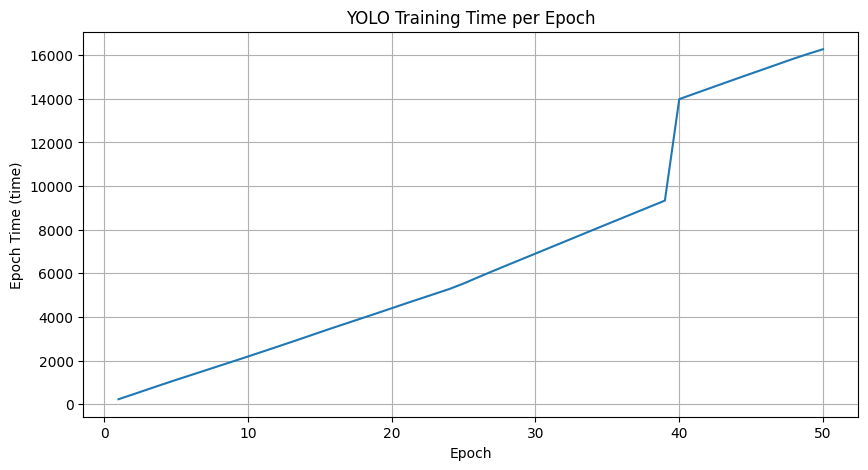

Saved: E:\dl_cv_mini_project\road_lane_detection\outputs\report_figures_yolo\yolo_epoch_time.png
Total training time (sum of epoch times): 344214.698


In [29]:
# Try common time columns
time_cols = [c for c in dfy.columns if "time" in c.lower()]

print("Time-like columns:", time_cols)

epoch_time = None

# If there is a per-epoch "time" column in seconds, use it directly
for c in time_cols:
    # Some runs have 'time' or 'time (s)' etc. We use the first numeric-looking one.
    if pd.api.types.is_numeric_dtype(dfy[c]):
        epoch_time = dfy[c].copy()
        epoch_time.name = c
        break

if epoch_time is None:
    print("No numeric time column found in results.csv. Skipping time plot (training plots are complete).")
else:
    plt.figure(figsize=(10,5))
    plt.plot(dfy["epoch"], epoch_time)
    plt.xlabel("Epoch")
    plt.ylabel(f"Epoch Time ({epoch_time.name})")
    plt.title("YOLO Training Time per Epoch")
    plt.grid(True)
    out = FIG_DIR / "yolo_epoch_time.png"
    plt.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", out.resolve())

    # Total time
    total = float(epoch_time.sum())
    print("Total training time (sum of epoch times):", total)


In [30]:
assert YOLO_BEST.exists(), f"best.pt missing: {YOLO_BEST.resolve()}"
yolo_model = YOLO(str(YOLO_BEST))
print("Loaded YOLO model:", YOLO_BEST.resolve())


Loaded YOLO model: E:\dl_cv_mini_project\road_lane_detection\runs\segment\train2\weights\best.pt


In [31]:
selected_txt = Path("outputs/random_test_results/selected_files.txt")
assert selected_txt.exists(), f"Missing selection file: {selected_txt.resolve()}"

picks = [x.strip() for x in selected_txt.read_text(encoding="utf-8").splitlines() if x.strip()]
print("Using images:", len(picks))
print("Example:", picks[0])


Using images: 20
Example: E:\dl_cv_mini_project\road_lane_detection\data\raw\tusimple\test_set\clips\0530\1492628131090172797_0\11.jpg


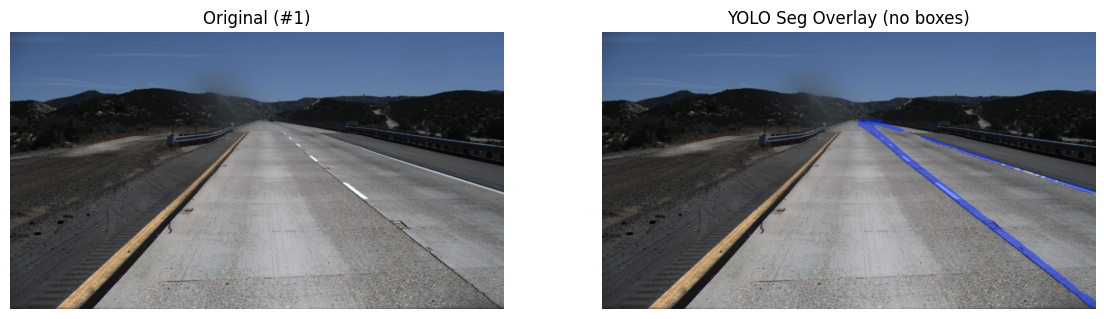

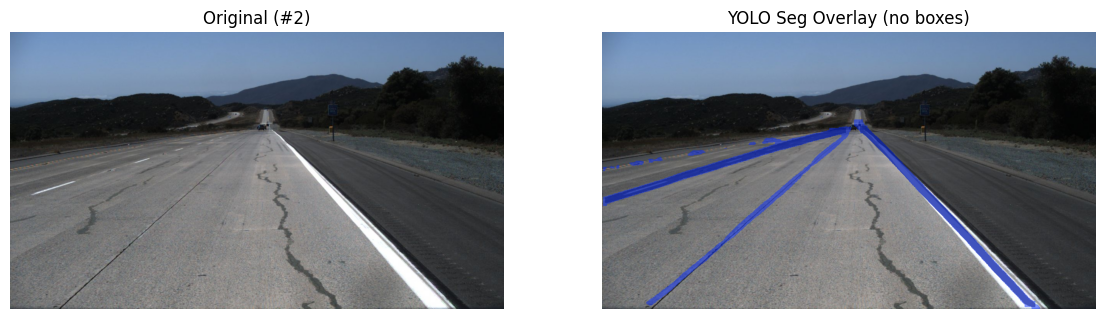

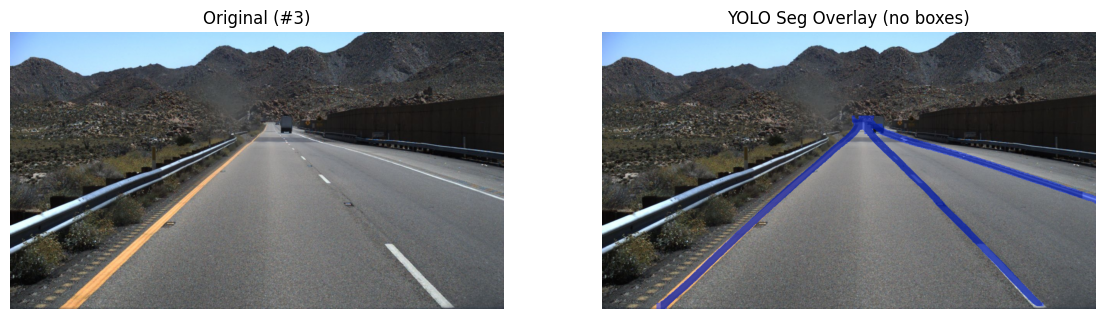

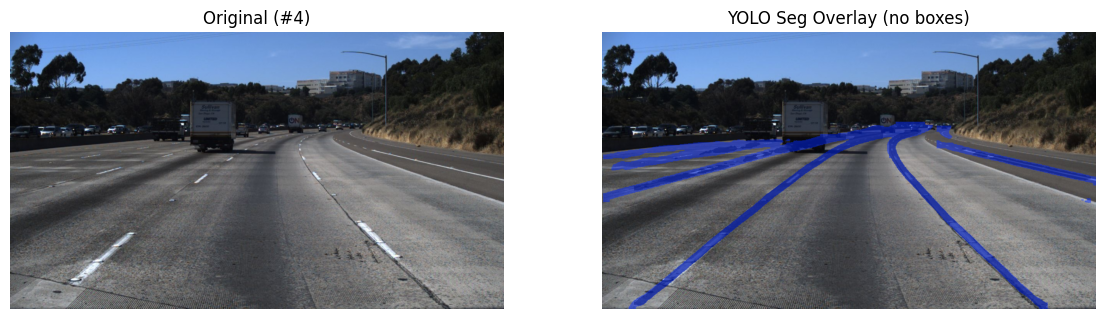

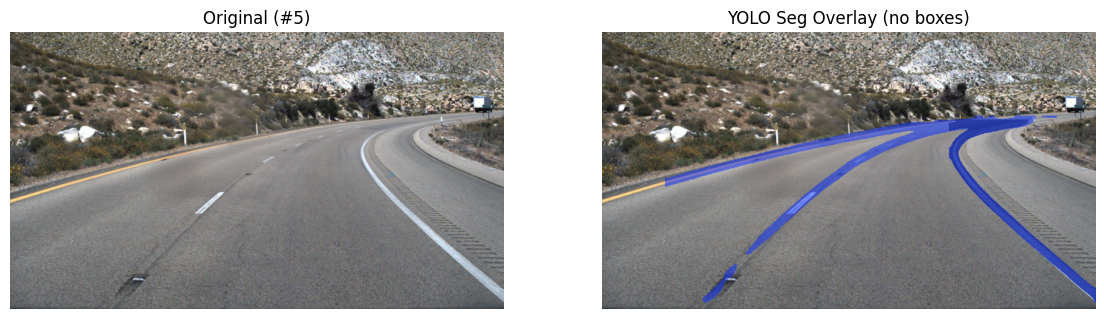

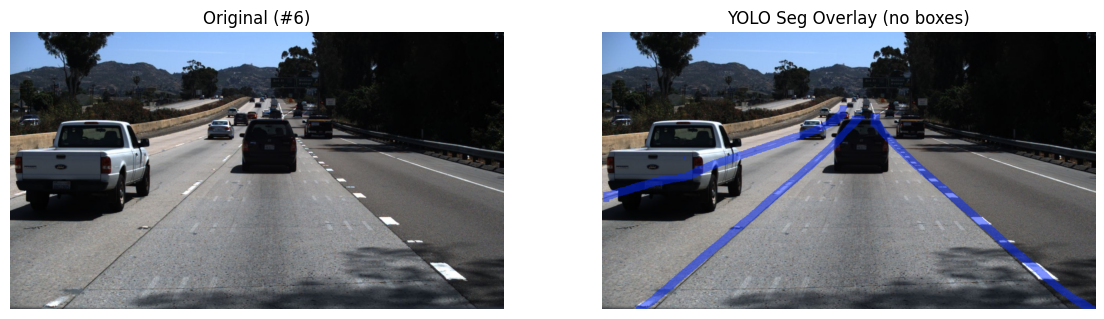

In [32]:
import matplotlib.pyplot as plt

def show_yolo_examples(show_n=6, imgsz=960, conf=0.20):
    show_n = min(show_n, len(picks))
    results = yolo_model.predict(
        source=picks[:show_n],
        imgsz=imgsz,
        conf=conf,
        iou=0.50,
        device=0,
        verbose=False
    )

    for i, r in enumerate(results, 1):
        # Original
        img_bgr = cv2.imread(r.path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # YOLO overlay (boxes disabled)
        vis_bgr = r.plot(boxes=False)        # BGR
        vis_rgb = cv2.cvtColor(vis_bgr, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(14,6))
        plt.subplot(1,2,1); plt.imshow(img_rgb); plt.title(f"Original (#{i})"); plt.axis("off")
        plt.subplot(1,2,2); plt.imshow(vis_rgb); plt.title("YOLO Seg Overlay (no boxes)"); plt.axis("off")
        plt.show()

show_yolo_examples(show_n=6, imgsz=960, conf=0.20)


In [33]:
OUT_YOLO = Path("outputs/yolo_predictions_same20_no_boxes_final")
OUT_YOLO.mkdir(parents=True, exist_ok=True)

results = yolo_model.predict(
    source=picks,
    imgsz=960,
    conf=0.20,
    iou=0.50,
    device=0,
    verbose=False
)

for i, r in enumerate(results, 1):
    vis = r.plot(boxes=False)  # BGR
    out_path = OUT_YOLO / f"{i:02d}__{Path(r.path).name}"
    cv2.imwrite(str(out_path), vis)

print("Saved YOLO outputs to:", OUT_YOLO.resolve())


Saved YOLO outputs to: E:\dl_cv_mini_project\road_lane_detection\outputs\yolo_predictions_same20_no_boxes_final


In [34]:
OUT_YOLO = Path("outputs/yolo_predictions_same20_no_boxes_final")
OUT_YOLO.mkdir(parents=True, exist_ok=True)

results = yolo_model.predict(
    source=picks,
    imgsz=960,
    conf=0.20,
    iou=0.50,
    device=0,
    verbose=False
)

for i, r in enumerate(results, 1):
    vis = r.plot(boxes=False)  # BGR
    out_path = OUT_YOLO / f"{i:02d}__{Path(r.path).name}"
    cv2.imwrite(str(out_path), vis)

print("Saved YOLO outputs to:", OUT_YOLO.resolve())


Saved YOLO outputs to: E:\dl_cv_mini_project\road_lane_detection\outputs\yolo_predictions_same20_no_boxes_final


In [35]:
import matplotlib.pyplot as plt
import numpy as np

assert "epoch" in df.columns, "UNet dataframe missing"
assert "epoch" in dfy.columns, "YOLO dataframe missing"

print("UNet epochs:", df["epoch"].max())
print("YOLO epochs:", dfy["epoch"].max())


UNet epochs: 15
YOLO epochs: 50


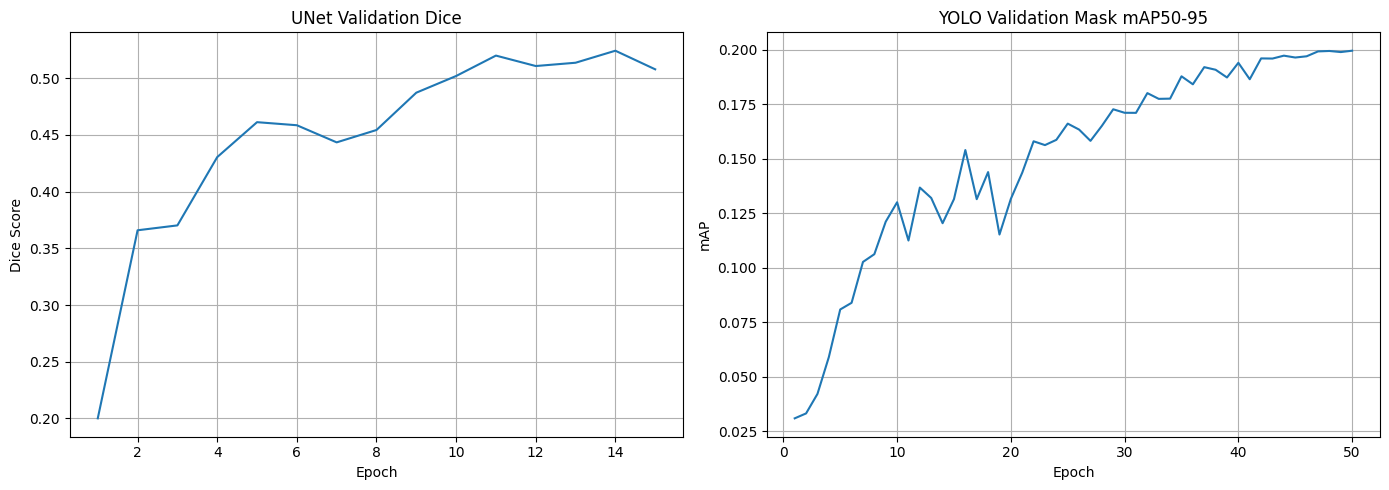

In [36]:
plt.figure(figsize=(14,5))

# UNet Dice
plt.subplot(1,2,1)
plt.plot(df["epoch"], df["val_dice"])
plt.title("UNet Validation Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.grid(True)

# YOLO Mask mAP50-95
plt.subplot(1,2,2)
plt.plot(dfy["epoch"], dfy["metrics/mAP50-95(M)"])
plt.title("YOLO Validation Mask mAP50-95")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.grid(True)

plt.tight_layout()
plt.show()


In [37]:
import pandas as pd

summary = pd.DataFrame({
    "Model": ["UNet + Hough", "YOLO-Seg"],
    "Primary Metric": ["Dice", "Mask mAP50-95"],
    "Best Value": [
        df["val_dice"].max(),
        dfy["metrics/mAP50-95(M)"].max()
    ],
    "Epoch @ Best": [
        int(df.loc[df["val_dice"].idxmax(), "epoch"]),
        int(dfy.loc[dfy["metrics/mAP50-95(M)"].idxmax(), "epoch"])
    ]
})

summary


,Model,Primary Metric,Best Value,Epoch @ Best
0,UNet + Hough,Dice,0.52420,14
1,YOLO-Seg,Mask mAP50-95,0.19958,50


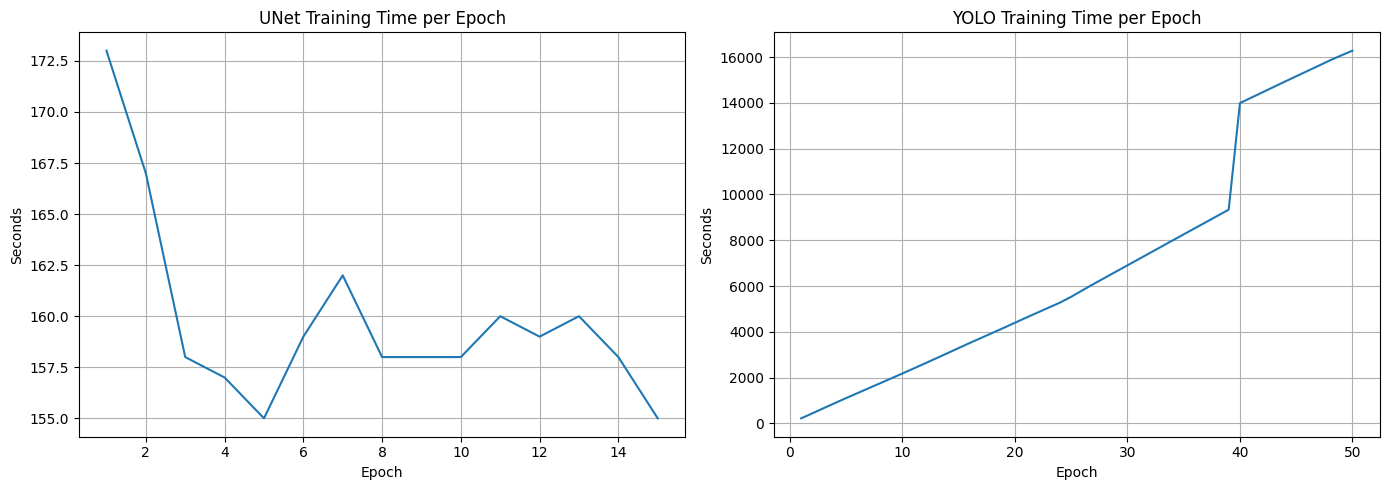

In [38]:
plt.figure(figsize=(14,5))

# UNet time
plt.subplot(1,2,1)
if df["epoch_time_sec"].notna().any():
    plt.plot(df["epoch"], df["epoch_time_sec"])
    plt.title("UNet Training Time per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Seconds")
    plt.grid(True)
else:
    plt.text(0.5, 0.5, "No UNet epoch time", ha="center")

# YOLO time (if available)
plt.subplot(1,2,2)
time_cols = [c for c in dfy.columns if "time" in c.lower()]
found = False
for c in time_cols:
    if pd.api.types.is_numeric_dtype(dfy[c]):
        plt.plot(dfy["epoch"], dfy[c])
        plt.title("YOLO Training Time per Epoch")
        plt.xlabel("Epoch")
        plt.ylabel("Seconds")
        plt.grid(True)
        found = True
        break

if not found:
    plt.text(0.5, 0.5, "YOLO epoch time not logged", ha="center")

plt.tight_layout()
plt.show()
